In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

# Two-sheet covering

Let's explore the two-sheet covering of the Klein bottle by the torus.

(See the Geogebra `.ggb` file for a visualisation and details)

Following this [question on Math.Stackexchange](https://math.stackexchange.com/questions/1073425/two-sheeted-covering-of-the-klein-bottle-by-the-torus), given a torus as a $[0,1]^2$ square with proper gluing of the sides,
we identify (glue) any two points $A$ and $B$ on a torus with such coordinates:

$A(x,y)\sim B\big(1-x, (y+\frac{1}{2}) \text{ mod } 1\big)$

So one should find such a mapping $f()$ that $f(A)=f(B)$ for any two such points. One such mapping is:

$$f_x(x,y) = \begin{cases}
2x, \text{  if  }0\leq x\leq1/2 \\
2-2x, \text{  if  }1/2< x\leq1
\end{cases} \\
f_y(x,y) = \begin{cases}
2y, \text{  if  }0\leq y\leq1/2 \\
2y-1, \text{  if  }1/2< y\leq1
\end{cases} 
$$

Let's play with it a bit:

In [20]:
def cover(points):
    """
    points is of shape = (n_points, 2)
    """
    xs, ys = points[:,0], points[:,1]
    xs_K, ys_K = [], []
    for i in range(points.shape[0]):
        x, y = xs[i], ys[i]
        xs_K.append(2*x if x <= 0.5 else 2-2*x)
        ys_K.append(2*y if y <= 0.5 else 2*y-1)
    return np.array([xs_K,ys_K]).T

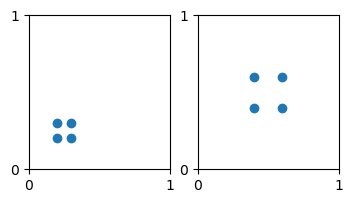

In [30]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.array([[0.2,0.2],
         [0.3,0.2],
         [0.2,0.3],
         [0.3,0.3]])


ax[0].scatter(points[:,0],points[:,1])

covers = cover(points)

ax[1].scatter(covers[:,0],covers[:,1])

In [36]:
x1 = np.random.multivariate_normal(mean=np.array([0.5,0.5]), 
                                   cov=np.array([[1,0],[0,1]]),
                                  size=100)

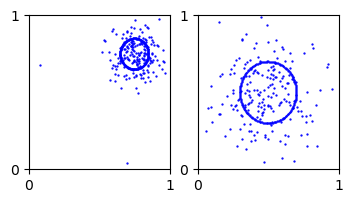

In [62]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.random.multivariate_normal(mean=np.array([0.75,0.75]), 
                                   cov=np.array([[0.01,0],[0,0.01]]),
                                  size=200)

points = points % 1


angles = np.linspace(0,2*np.pi,200)
circle = np.array([np.cos(angles), np.sin(angles)]).T * 0.1
circle += 0.75

ax[0].scatter(points[:,0],points[:,1],s=0.4,color='blue')
ax[0].scatter(circle[:,0],circle[:,1],s=0.3,color='blue')

covers = cover(points)

c_circle = cover(circle)

ax[1].scatter(covers[:,0],covers[:,1],s=0.4,color='blue')
ax[1].scatter(c_circle[:,0],c_circle[:,1],s=0.3,color='blue')

In [51]:
circle

array([[0.6       , 0.59979867, 0.59919548, 0.59819287, 0.59679487,
        0.59500711, 0.59283679, 0.59029265, 0.58738494, 0.58412535,
        0.58052703, 0.57660444, 0.5723734 , 0.56785094, 0.56305527,
        0.55800569, 0.55272255, 0.54722711, 0.5415415 , 0.53568862,
        0.52969204, 0.52357589, 0.51736482, 0.51108382, 0.50475819,
        0.4984134 , 0.492075  , 0.48576852, 0.47951933, 0.47335262,
        0.4672932 , 0.46136549, 0.45559334, 0.45      , 0.44460799,
        0.43943903, 0.43451393, 0.42985251, 0.42547356, 0.42139469,
        0.41763234, 0.41420166, 0.41111646, 0.40838915, 0.40603074,
        0.4040507 , 0.40245702, 0.40125611, 0.40045281, 0.40005035,
        0.40005035, 0.40045281, 0.40125611, 0.40245702, 0.4040507 ,
        0.40603074, 0.40838915, 0.41111646, 0.41420166, 0.41763234,
        0.42139469, 0.42547356, 0.42985251, 0.43451393, 0.43943903,
        0.44460799, 0.45      , 0.45559334, 0.46136549, 0.4672932 ,
        0.47335262, 0.47951933, 0.48576852, 0.49